# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Christopher Currie

**Date:** 09/07/26

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


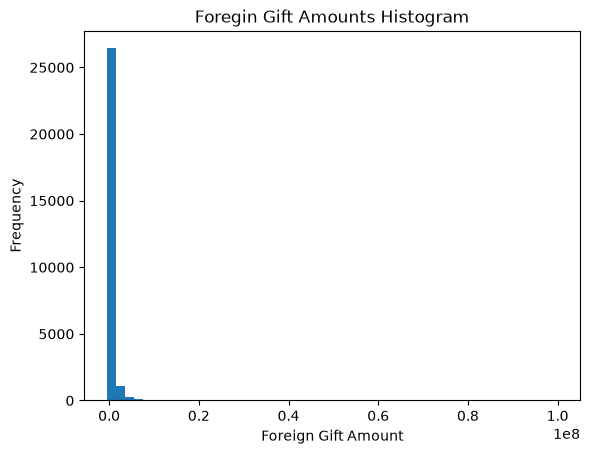

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#1. Load the `./data/ForeignGifts_edu.csv` dataset.
import pandas as pd
df = pd.read_csv('./data/ForeignGifts_edu.csv')

#2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
plt.hist(df['Foreign Gift Amount'], bins =50)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title("Foregin Gift Amounts Histogram")

#stats for describing
print(df['Foreign Gift Amount'].describe())

#the amounts are heavily right skwed, the majoiry of the gifts are small but there a few massive figts that push the average to 588233

In [ ]:
# For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

#Value counts table and proportions for Gift Type
counts = df['Gift Type'].value_counts()
proportions = df['Gift Type'].value_counts(normalize=True)


print (counts)
print (proportions)
#summary for proportions
summary = pd.DataFrame({
    'Count': counts,
    'Proportion': proportions,
    'Percentage': (proportions * 100).map('{:.2f}%'.format)
})

print(summary)

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
               Count  Proportion Percentage
Gift Type                                  
Contract       17274    0.612097     61.21%
Monetary Gift  10936    0.387513     38.75%
Real Estate       11    0.000390      0.04%


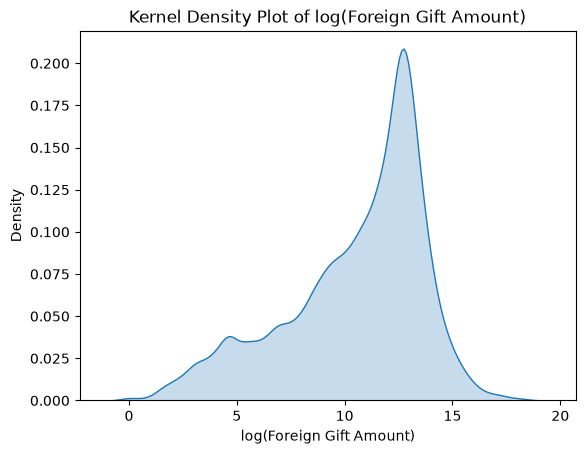

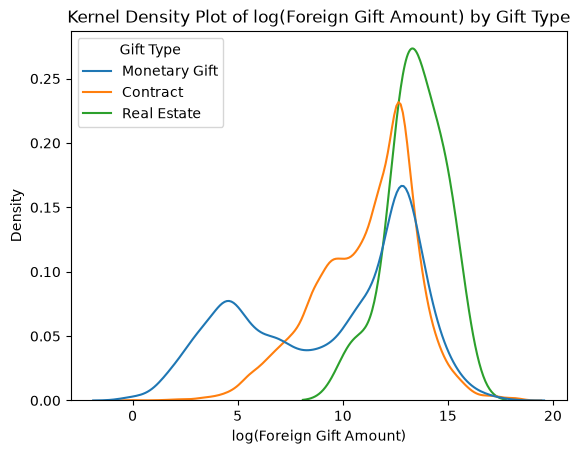

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#Create a kernel density plot of the log of `Foreign Gift Amount`, 
# and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. 
# Do you notice any patterns?


# Filter positive amounts to take the log
df_pos = df[df['Foreign Gift Amount'] > 0].copy()
df_pos['log_amount'] = np.log(df_pos['Foreign Gift Amount'])

# log of 'Foreign Gift Amount'
sns.kdeplot(df_pos['log_amount'], fill=True)
plt.title('Kernel Density Plot of log(Foreign Gift Amount)')
plt.xlabel('log(Foreign Gift Amount)')
plt.show()

# conditional on Gift Type
sns.kdeplot(data=df_pos, x='log_amount', hue='Gift Type', common_norm=False)
plt.title('Kernel Density Plot of log(Foreign Gift Amount) by Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.show()


#patterns I notice: the log helpes fix the skewing issue and there is much better bell shaped curve 
# and real esate gifts are shifted farthers right which means they have the highest dollar amounts overall.
# Montery gits include more low value gifts compared to there counterparts.


In [19]:
#5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

#top 15 by number of gifts
t15G = df['Country of Giftor'].value_counts().head(15)
print("Top 15 by number of gifts:") #shown in output 
print(t15G) #prints top 15 countries in mumber of gifts

#top 15 by amount given
t15A = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("\n Top 15 by amount given:") # shown in output
print(t15A)

Top 15 by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

 Top 15 by amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202


In [24]:
#6. Which giftors provide the most money, in total?
 #Qatar Foundation: ~$1.17 Billion ($1,166,503,744)
# Qatar Foundation/Qatar National Res: ~$796.20 Million ($796,197,000)
# Qatar Foundation for Education: ~$373.95 Million ($373,945,215)

#above are the top 3 from the code below, more can be seen by running the code and changing the '10' at the end

# Top giftors by total amount given
top = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top) #

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]